In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings


dataset=pd.read_csv("Wine.csv")
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)

In [15]:
encoded_df = pd.get_dummies(dataset,dtype=int,drop_first=True)
print("Dataset encoded successfully")

Dataset encoded successfully


In [16]:
# Independent and Dependent variables

x = encoded_df.iloc[:, :-1].values
featurenames = encoded_df.iloc[:, :-1].columns

y = encoded_df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=0
)

In [17]:
def standardscaler(x_train,x_test):
    sc=StandardScaler()
    x_train = sc.fit_transform(x_train)
    x_test = sc.transform(x_test)
    return x_train,x_test

def perform_pca(x_train,x_test,n):
    pca = PCA(n_components = n)
    x_train = pca.fit_transform(x_train)
    x_test = pca.transform(x_test)
    print(pca.components_)
    most_influential_features = np.argmax(np.abs(pca.components_), axis=1)
    # This will give the maximum PCA component index [10,6] something for 2 PCA component
    
    print(most_influential_features)
    selected_features = featurenames[most_influential_features]
    explained_variance = pca.explained_variance_ratio_
    print("Explained Variance Ratio:")
    print(explained_variance)
    return x_train,x_test,explained_variance,selected_features

def cm_prediction(classifier,x_test):
    y_pred = classifier.predict(x_test)
    
    from sklearn.metrics import confusion_matrix
    cm=confusion_matrix(y_test,y_pred)
    
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import classification_report
    Accuracy = accuracy_score(y_test,y_pred)
    report=classification_report(y_test,y_pred)
    return classifier,Accuracy,report,x_test,y_test,cm

def accuracy_table(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf):
    dataframe  = pd.DataFrame(index=[f"PCA Components: {len(explained_variance)}"],columns=['Logistic','SVMl','SVMnl','KNN','Navie','Decision','Random'])
    for number,idex in enumerate(dataframe.index):      
        dataframe['Logistic'][idex]=acclog[number]       
        dataframe['SVMl'][idex]=accsvml[number]
        dataframe['SVMnl'][idex]=accsvmnl[number]
        dataframe['KNN'][idex]=accknn[number]
        dataframe['Navie'][idex]=accnav[number]
        dataframe['Decision'][idex]=accdes[number]
        dataframe['Random'][idex]=accrf[number]
    return dataframe

def logistic(x_train,y_train,x_test):
    from sklearn.linear_model import LogisticRegression
    classifier = LogisticRegression(random_state = 0)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

def svm_linear(x_train,y_train,x_test):
    from sklearn.svm import SVC
    classifier = SVC(kernel = 'linear', random_state = 0)
    classifier.fit(x_train, y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return  classifier,Accuracy,report,x_test,y_test,cm

def svm_NL(x_train,y_train,x_test):        
    from sklearn.svm import SVC
    classifier = SVC(kernel = 'rbf', random_state = 0)
    classifier.fit(x_train, y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return  classifier,Accuracy,report,x_test,y_test,cm

def Navie(x_train,y_train,x_test):       
    from sklearn.naive_bayes import GaussianNB
    classifier = GaussianNB()
    classifier.fit(x_train, y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return  classifier,Accuracy,report,x_test,y_test,cm   

def knn(x_train,y_train,x_test):
    from sklearn.neighbors import KNeighborsClassifier
    classifier = KNeighborsClassifier(n_neighbors = 5,metric = "minkowski",p=2)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

def Decision(x_train,y_train,x_test):
    from sklearn.tree import DecisionTreeClassifier
    classifier = DecisionTreeClassifier(criterion="entropy",random_state=0)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

def random(x_train,y_train,x_test):
    from sklearn.ensemble import RandomForestClassifier
    classifier = RandomForestClassifier(n_estimators=10,criterion="entropy",random_state=0)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state=0)
x_train,x_test = standardscaler(x_train,x_test)
x_train,x_test,explained_variance,selected_features = perform_pca(x_train,x_test,5);
acclog=[]
accsvml=[]
accsvmnl=[]
accknn=[]
accnav=[]
accdes=[]
accrf=[]
print(featurenames)
print("Selected Principal Components")
print(selected_features)

[[ 0.12959991 -0.24464064 -0.01018912 -0.24051579  0.12649451  0.38944115
   0.42757808 -0.30505669  0.30775255 -0.11027186  0.30710508  0.37636185
   0.2811085 ]
 [ 0.49807323  0.23168482  0.31496874 -0.02321825  0.25841951  0.1006849
   0.02097952  0.0399057   0.06746036  0.53087111 -0.27161729 -0.16071181
   0.36547344]
 [-0.1383815   0.08422378  0.63988217  0.62195017  0.02997765  0.17115651
   0.12464239  0.17100464  0.15155321 -0.14612801  0.10692701  0.17144241
  -0.13178214]
 [-0.24199813 -0.03501265 -0.00978418  0.0922443   0.82788074 -0.16969861
  -0.12346501 -0.39521252  0.06413801 -0.10827243 -0.05295673 -0.14487111
  -0.07973043]
 [-0.17279973  0.58431883 -0.26362755 -0.02622374 -0.08753303  0.16632648
   0.10686668 -0.10735201  0.52323021  0.02931966 -0.38019616  0.14033771
  -0.24774953]]
[6 9 2 4 1]
Explained Variance Ratio:
[0.36884109 0.19318394 0.10752862 0.07421996 0.06245904]
Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols'

In [19]:
classifier,Accuracy,report,x_test,y_test,cm=logistic(x_train,y_train,x_test)
acclog.append(Accuracy)

classifier,Accuracy,report,x_test,y_test,cm=svm_linear(x_train,y_train,x_test)  
accsvml.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=svm_NL(x_train,y_train,x_test)  
accsvmnl.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=knn(x_train,y_train,x_test)  
accknn.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=Navie(x_train,y_train,x_test)  
accnav.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=Decision(x_train,y_train,x_test)  
accdes.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=random(x_train,y_train,x_test)  
accrf.append(Accuracy)

In [20]:
accuracy_table(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)
#3

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
PCA Components: 5,0.972222,0.944444,1.0,1.0,1.0,0.972222,0.972222


In [21]:
accuracy_table(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)
#6

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
PCA Components: 5,0.972222,0.944444,1.0,1.0,1.0,0.972222,0.972222


In [22]:
accuracy_table(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)
#4

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
PCA Components: 5,0.972222,0.944444,1.0,1.0,1.0,0.972222,0.972222


In [23]:
accuracy_table(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)
#5

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
PCA Components: 5,0.972222,0.944444,1.0,1.0,1.0,0.972222,0.972222


Selected Principal Components
Index(['Flavanoids', 'Color_Intensity', 'Ash', 'Magnesium', 'Malic_Acid'], dtype='object')


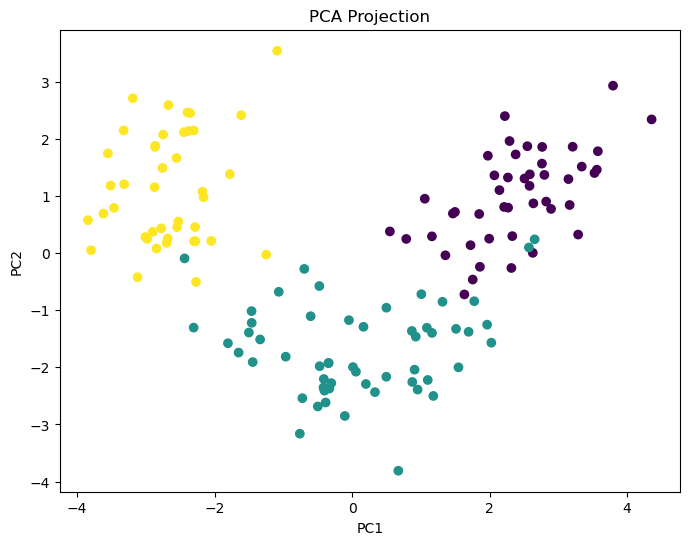

In [24]:
print("Selected Principal Components")
print(selected_features) #for 3 dimensions

plt.figure(figsize=(8,6))

plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")

plt.show()